In [1]:
## IMPORTS
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.animation import FuncAnimation
import numpy as np

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksensor import kSensor
from kwave.ksource import kSource
from kwave.kspaceFirstOrder2D import kspaceFirstOrder2D
from kwave.utils.signals import tone_burst
from kwave.kWaveSimulation import SimulationOptions
from kwave.options.simulation_execution_options import SimulationExecutionOptions
from kwave.utils.colormap import get_color_map

In [2]:
## SIMULATION SETUP
c0 = 1540                       # [m/s] Speed of sound
rho0 = 1000                     # [kg/m^3] Density of water
source_f0 = 1e6                 # [Hz] Source frequency
source_amp = 1e6                # [Pa] Source amplitude
source_cycles = 2               # Number of cycles in the pulse

grid_size_x = 40e-3             # [m] Grid size in x (NB: Depth in k-Wave)
grid_size_y = 40e-3             # [m] Grid size in z (NB: Width in k-Wave)
ppw = 5                         # Points per wavelength
cfl = 0.3                       # Related to the time resolution, lower is more accurate (no need to change)

viz_t = grid_size_y / 2 / c0 * 0.75      # Visualization time [s]

aperture = 2*1e-2                 # 0.02 m -  2 cm


In [ ]:
# GRID SETUP
dx = c0 / (ppw * source_f0)     # Grid resolution
Nx = round(grid_size_x / dx)    # Number of grid points in x, NB: This is depth
Ny = round(grid_size_y / dx)    # Number of grid points in y, NB: This is width (lateral)
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0, cfl);         # Make time array based on the Courant-Friedrichs-Lewy (CFL) condition
Numb_indices_aperture = round(aperture/dx)

In [37]:
# DELAY PROFILE
def r_dist(x,y,z):
    return 1

class Point:
    def __init__(self,x,y,z):
        self.x = x
        self.y = y
        self.z = z

center_element = Point(0,0,0)
focal_point = Point(0,0,0)

def distance(point1: Point, point2: Point):
    return np.sqrt((point1.x - point2.x)**2+(point1.y - point2.y)**2+(point1.z - point2.z)**2)

rc = 0 # Distance from focus to center element
ri = 0 # Distance from focus to element i

def timeDelay(rc, ri):
    return (1/c0)*(rc-ri)

In [ ]:
## SETUP AND RUN SIMULATION

# SOURCE SETUP

# Source signal, Gaussian pulse
source_sig = source_amp * tone_burst(1 / kgrid.dt, source_f0, source_cycles)


# Define kWave source object
source = kSource()
source.p_mask = np.zeros_like(kgrid.x)

for i in range(Numb_indices_aperture):
    def __altSign__(i) -> int: #gives every other negative as well as keeping the splitting i evenly around 0 
        cut = i // 2 
        if i % 2 == 0: return -cut
        else: return cut + 1

    source.p_mask[round(kgrid.Nx/2)+__altSign__(i), 0] = 1
    #print(round(kgrid.Nx/2)+__altSign__(i))

source.p = source_sig                                       # Source signal (pressure source)

# Setup sensor
sensor = kSensor(record=['p', 'p_max'])                     # Sensor object, record pressure and maximum pressure
sensor.mask = np.ones_like(kgrid.x)                    # Sensor mask, all grid points 

# Setup medium
medium = kWaveMedium(sound_speed=c0, density=rho0)          # Define medium object, simple homogeneous medium


In [5]:
# Setup simulation options
simulation_options = SimulationOptions(
    pml_auto=True,
    pml_inside=False,
    save_to_disk=True,
    data_cast='single',
)
execution_options = SimulationExecutionOptions(is_gpu_simulation=False, num_threads=1)

# Run 2D simulation (to save some time)
sensor_data = kspaceFirstOrder2D(kgrid=kgrid, medium=medium, source=source, sensor=sensor, simulation_options=simulation_options, execution_options=execution_options)

┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      1 │
│ Processor name:                                               │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  162 x 162 │
│ Medium type:                                               2D │
│ Simulation time steps:                                    613 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [ ]:
# Extract pressure field from
p_field = np.reshape(sensor_data["p"], (kgrid.Nt, Nx, Ny), order="F")   # Stored in Fortran ordering for some reason
#p_max_field = np.reshape(sensor_data['p_max'], (Nx, Ny), order="F")

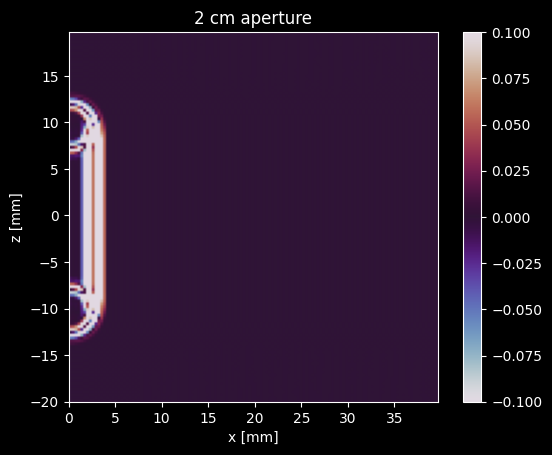

In [30]:

# Beam profile
# p_max = np.abs(p_max_field)
# p_max /= np.max(p_max)
# p_max_db = 10*np.log10(p_max)

## VISUALIZATION
plt.style.use('dark_background')

# Get frame number to plot
N_frame = np.round(np.where(kgrid.t_array[0] > viz_t)[0][0]).astype(int)   # Number of frames to visualize

# Normalize frames based on the maximum value over all frames
max_value = np.max(np.abs(p_field))
p_plot = p_field / max_value

cmap = 'twilight'
extent = np.array([kgrid.y_vec[0]+20e-3, kgrid.y_vec[-1]+20e-3, kgrid.x_vec[0], kgrid.x_vec[-1]])*1e3

# Create a figure and axis
fig, ax = plt.subplots()
image = plt.imshow(p_plot[N_frame], cmap=cmap, vmin=-0.1, vmax=0.1, extent=extent)
ax.imshow(p_plot[N_frame-120], cmap=cmap, extent=extent, vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.xlabel('x [mm]')
plt.ylabel('z [mm]')
plt.title('2 cm aperture')
plt.show()
